# Simulation 3 — Ring resonator Q-factor and FSR

A **ring resonator** filters wavelengths: on resonance the round-trip phase satisfies $2\\pi r n_{\\mathrm{eff}} = m\\lambda$. The transmission spectrum shows periodic notches with free spectral range $\\mathrm{FSR} \\approx \\lambda^2 / (n_g L)$ and linewidth set by coupling and loss (Q-factor).

We inject a broadband Gaussian pulse, record bus flux, and fit a Lorentzian to the deepest resonance.

In [1]:
import matplotlib.pyplot as plt
import tidy3d.web as web

from fdtd_pic.analytics.ring import analytical_fsr_hz, fit_resonance, measured_fsr
from fdtd_pic.config import RING_RADIUS
from fdtd_pic.plotting import apply_style, save_figure
from fdtd_pic.ring import build_ring_simulation, extract_transmission_spectrum

apply_style()

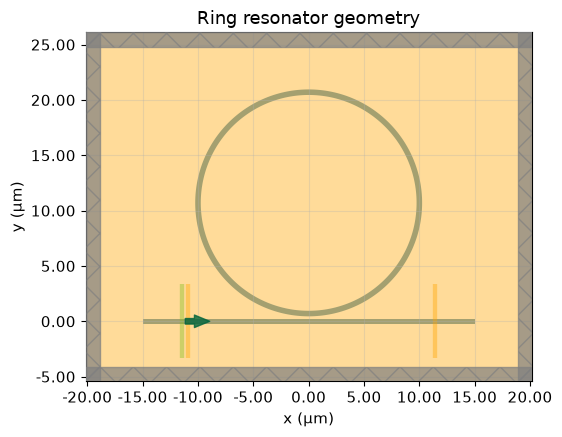

In [2]:
sim = build_ring_simulation()
sim.plot(z=0)
plt.title('Ring resonator geometry')
plt.show()


# ring gap at 3 0clock seems to be the way the polygons are defined, looking into a fix.
# fixed! - see commit 105cfae


# ahhhh i missed that the ring was clipped so the ring actually isnt connectted to itself, need to fix this and re-run

# think i fixed, waiting to commit.

In [4]:
# simulating and web run

sim_data = web.run(sim, task_name='ring_broadband', verbose=True)
freqs, transmission = extract_transmission_spectrum(sim_data)

fig, ax = plt.subplots()
ax.plot(freqs / 1e12, transmission)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Through transmission')
ax.set_title('Ring transmission spectrum')
save_figure(fig, '../assets/ring_transmission_spectrum.png')
plt.show()

19:30:57 UTC WARNING: Simulation has 6.15e+06 time steps. The 'run_time' may be 
             unnecessarily large, unless there are very long-lived resonances.  

19:30:58 UTC Created task 'ring_broadband' with resource_id                     
             'fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=14535441;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=14535442;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\taskId]8;;\]8;id=14535441;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\=]8;;\]8;id=14535443;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\fdve]8;;\]8;id=14535441;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\-3d738c79-0af]8;;\
             ]8;id=14535441;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3\4-4644-99d3-5f24b5a0f3d3']8;;\.

             Task folder: ]8;id=14535446;https://tidy3d.simulation.cloud/folders/folder-ad4e7e1c-cdcb-44bd-86bf-3106f5c2bba1\'default']8;;\.

Output()

19:31:02 UTC Estimated FlexCredit cost: 41.618. Minimum cost depends on task    
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             ERROR: error=Your simulation is aborted due to insufficient        
             balance. You can reduce the simulation cost with                   
             'https://www.flexcompute.com/tidy3d/learning-center/faq/#how-can-i-
             reduce-the-simulation-cost' or click                               
             'https://tidy3d.simulation.cloud/account?tab=plan' to add more     
             credits.; 4000000001; BAD_REQUEST [HTTP 400 POST                   
             https://tidy3d-api.simulation.cloud/tidy3d/tasks/fdve-3d738c79-0af4
             -4644-99d3-5f24b5a0f3d3/submit]                                    

WebError: error=Your simulation is aborted due to insufficient balance. You can reduce the simulation cost with 'https://www.flexcompute.com/tidy3d/learning-center/faq/#how-can-i-reduce-the-simulation-cost' or click 'https://tidy3d.simulation.cloud/account?tab=plan' to add more credits.; 4000000001; BAD_REQUEST [HTTP 400 POST https://tidy3d-api.simulation.cloud/tidy3d/tasks/fdve-3d738c79-0af4-4644-99d3-5f24b5a0f3d3/submit]

Resonance f0 = 179.491 THz
Q = 5
FSR (sim) ~ 2.3210 THz
FSR (analytical) ~ 1.1360 THz


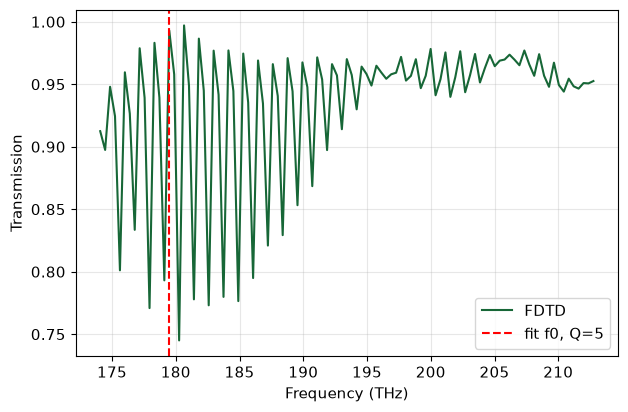

In [4]:
fit = fit_resonance(freqs, transmission)
fsr_sim = measured_fsr(freqs, transmission)
fsr_analytical_hz = analytical_fsr_hz(RING_RADIUS)

print(f'Resonance f0 = {fit.f0/1e12:.3f} THz')
print(f'Q = {fit.q_factor:.0f}')
print(f'FSR (sim) ~ {fsr_sim/1e12:.4f} THz' if fsr_sim == fsr_sim else 'FSR (sim): n/a')
print(f'FSR (analytical) ~ {fsr_analytical_hz/1e12:.4f} THz')

fig, ax = plt.subplots()
ax.plot(freqs / 1e12, transmission, label='FDTD')
ax.axvline(fit.f0 / 1e12, color='r', ls='--', label=f'fit f0, Q={fit.q_factor:.0f}')
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Transmission')
ax.legend()
save_figure(fig, '../assets/ring_lorentzian_fit.png')
plt.show()

In [3]:
sim = build_ring_simulation()

MAX_STEPS = 9_000_000  # stay under 10M
n = sim.num_time_steps
print(f"steps = {n:.2e}, run_time = {sim.run_time*1e9:.3f} ns")

if n > MAX_STEPS:
  scale = MAX_STEPS / n
  new_rt = sim.run_time * scale
  print(f"TOO LONG — set run_time = {new_rt:.3e} s ({new_rt*1e9:.3f} ns)")

steps = 6.15e+06, run_time = 0.500 ns


In [5]:
python -c "import tidy3d.web as web; a = web.account(); print(a)"

SyntaxError: invalid syntax (3561540883.py, line 1)

## Key takeaway

Gap controls bus–ring coupling and therefore Q. Compare simulated FSR and Q to analytical estimates; large discrepancies usually mean resolution, PML, or geometry issues.